In [1]:
#!pip install nbconvert[webpdf]
#!pip install openpyxl

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy as stats
import base64

from functools import reduce
from urllib.parse import urlencode, urlunparse,quote, quote_plus
from IPython.display import FileLink,display, HTML

In [3]:
import os
contenu = os.listdir('../../../')
print(contenu)

['13 x 18 cm. (2).pdf', '20102020 Contrat Prestation FOUR SARL - v1.docx', '2021 - 01.2022 Final Process Review.pdf', '20210203_ODISSEO_STEERCO.pptx', '4500128037  Poste10 - NEBIG VERPAKKINGEN BV.docx', '45xxx  Poste20 - ddd.docx', 'Accord Commercial  1 Rexel France_2019 - Adisseo.pdf', 'amtn2005.xls', 'Analyse panel fournisseur 2013-2014.ppt', 'Archilog - Contrat 2020 - 30.3.2020.pdf', 'Avenant 2 - Contrat cadre Technip-ADisseo.docx', 'bilan decembre.pdf', 'Blocs-notes OneNote', 'cerfa_11796-01.pdf', 'CertExchange.p7c', 'chrome', 'Classeur1 (Enregistré automatiquement).xlsx', 'Classeur1.xlsx', 'Classeur2(Récupération automatique).xlsx', 'Commande 4210071651 KSB SAS POMPES - Annexe 1A.pdf', 'Commande 4210151994 CRISTAL LIFE (1).pdf', 'Commande 4220029280 SUEZ RR IWS CHEMICALS FRANCE-signed.pdf', 'Commande 4220031812 SUEZ RR IWS CHEMICALS FRANCE.pdf', 'Commande 4230002260 NALCO FRANCE.pdf', 'Commande 4230002264 NALCO FRANCE.pdf', 'Commande 4230002275 NALCO FRANCE.pdf', "Contract 2022 H1

In [4]:
def read_cred():
    f = open("../../cred.txt", "r")
    cred = f.read()
    f.close()
    return cred
urlBase = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?'
credentials = read_cred()

In [5]:
def get_OI(url,start,end,interval='PT1M',tag='xx',auth='xx',hS='00',hF='23'):
	url_all =url+'data-reference='+tag+'&aggregation=TIME'+'&aggregation-function=MEAN'+"&from="+start+"T"+hS+"%3A00%3A00.000Z&to="+end+"T"+hF+"%3A59%3A59.000Z&aggregation-period="+interval
	#print(url_all,auth)
	d_data = pd.read_json(url_all,storage_options={ 'Authorization': 'basic '+ auth})
	# print(d_data['values'][0])
	arr = np.asarray(np.asarray(d_data['values'])[0])
	return d_data['values'][0]

In [6]:
def get_data(tags,start, end):
    liste = list(range(0))
    for tag in tags:
        urlTag = quote(tag, safe=':/?#[]@!$&\'()*+,;=')
        data = get_OI(urlBase,start,end,'PT20M',urlTag,credentials,'00','23')
        df = pd.DataFrame(data)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp')
        df = df.rename(columns={'value':tag})
        liste.append(df)
    return liste

In [7]:
def merge_data(liste):
    df = reduce(lambda left,right : pd.merge(left, right,left_index=True,right_index=True,how='outer'),liste)
    return df

In [8]:
def detecter_campagnes(df, seuil_jours=30):
    """
    Détecte les campagnes et ajoute plusieurs colonnes d'information
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    
    df = df.sort_index()
    
    # Calculer les différences
    diff_jours = df.index.to_series().diff().dt.days
    
    # Détecter les nouvelles campagnes
    nouvelle_campagne = (diff_jours > seuil_jours) | (diff_jours.isna())
    
    # Numéro de campagne
    df['campagne'] = nouvelle_campagne.cumsum()
    
    # Date de début de chaque campagne
    df['debut_campagne'] = df.groupby('campagne').apply(lambda x: x.index.min()).loc[df['campagne']].values
    
    # Nombre de jours depuis le début de la campagne
    df['jour_campagne'] = (df.index - df['debut_campagne']).days
    
    return df


In [9]:
def detecter_campagnes_v2(df, seuil_jours=3):
    df = df.sort_index().copy()

    # Calcul de l'écart de temps entre deux points consécutifs
    deltas = df.index.to_series().diff()

    # Nouvelle campagne si delta > seuil_jours
    nouvelle_campagne = deltas > pd.Timedelta(days=seuil_jours)

    # Numérotation : on cumule les True
    df["campagne"] = nouvelle_campagne.cumsum() + 1

    # Ajout colonne mois-année au format mm-aa
    df["mois_annee"] = df.index.strftime("%y-%m")
    #df["mois_annee_dt"] = pd.to_datetime(df.index.to_period('M').astype(str))
    df["mois_annee_dt"] = df.index.tz_localize(None).to_period('M').to_timestamp()
    #df["mois_annee_dt"] = pd.to_datetime(df["mois_annee"], format="%m-%y")

    return df

In [10]:
def separer_elements(df):
    """
    Sépare le dataframe en deux : un pour l'élément M et un pour l'élément R.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes timestamp, M_* et R_*
    
    Returns:
    --------
    tuple (df_M, df_R)
        df_M : DataFrame avec timestamp, M_Poids, M_UV_Auto, M_Labo, M_Num, M_Campagne
        df_R : DataFrame avec timestamp, R_Poids, R_UV_Auto, R_Labo, R_Num, R_Campagne
    """
    
    # DataFrame pour M : ne garder que les lignes où M_Poids est non nul
    df_M = df[df['A1000M_Poids'].notna()][['A1000M_Poids', 'A1000M_UV_Auto', 'A1000M_Labo', 'A1000M_Num', 'M_Campagne']].copy()
    df_M = df_M.rename(columns={'M_Campagne':'campagne'})
    
    # DataFrame pour R : ne garder que les lignes où R_Poids est non nul
    df_R = df[df['A1000R_Poids'].notna()][['A1000R_Poids', 'A1000R_UV_Auto', 'A1000R_Labo', 'A1000R_Num', 'R_Campagne']].copy()
    df_R = df_R.rename(columns={'R_Campagne':'campagne'})
        
    return df_M, df_R

In [11]:
def ajouter_element_campagne(df, fill_empty=False):
    """
    Ajoute trois colonnes au dataframe : 'Element' (M ou R), 'M_Campagne' et 'R_Campagne'.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame contenant les colonnes M_Poids et R_Poids
    fill_empty : bool, default=False
        Si True, propage l'élément sur les lignes vides (forward fill)
        Si False, les lignes sans données restent à NaN
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame avec les nouvelles colonnes 'Element', 'M_Campagne' et 'R_Campagne'
    """
    import numpy as np
    
    # Créer une copie pour ne pas modifier l'original
    df_result = df.copy()
    
    # Identifier l'élément actif basé uniquement sur M_Poids et R_Poids
    df_result['Element'] = np.where(
        df_result['A1000M_Poids'].notna(),
        'M',
        np.where(
            df_result['A1000R_Poids'].notna(),
            'R',
            np.nan
        )
    )
    
    # Détecter les transitions d'élément sur toutes les lignes (y compris NaN)
    element_change = (df_result['Element'] != df_result['Element'].shift()) & df_result['Element'].notna()
    
    # Initialiser les colonnes de campagne
    df_result['M_Campagne'] = np.nan
    df_result['R_Campagne'] = np.nan
    
    # Compteurs de campagne
    m_counter = 0
    r_counter = 0
    
    # Parcourir le dataframe pour attribuer les numéros de campagne
    for idx in df_result.index:
        if df_result.loc[idx, 'Element'] == 'M':
            if element_change.loc[idx]:
                m_counter += 1
            df_result.loc[idx, 'M_Campagne'] = m_counter
        elif df_result.loc[idx, 'Element'] == 'R':
            if element_change.loc[idx]:
                r_counter += 1
            df_result.loc[idx, 'R_Campagne'] = r_counter
    
    # S'assurer que les compteurs commencent à 1 si des valeurs existent
    if df_result['M_Campagne'].notna().any() and df_result['M_Campagne'].min() == 0:
        df_result.loc[df_result['M_Campagne'].notna(), 'M_Campagne'] += 1
    if df_result['R_Campagne'].notna().any() and df_result['R_Campagne'].min() == 0:
        df_result.loc[df_result['R_Campagne'].notna(), 'R_Campagne'] += 1
    
    return df_result

In [12]:
def reincrementer_campagnes_par_temps(df, jours_seuil=3):
    """
    Réincrémente les numéros de campagne en fonction des écarts de temps entre les mesures.
    Si l'écart entre deux lignes dépasse le seuil, le numéro de campagne est incrémenté.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame avec timestamp en index (datetime) et une colonne de campagne
    jours_seuil : int or float, default=3
        Nombre de jours au-delà duquel on incrémente la campagne
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame avec les numéros de campagne mis à jour
    """

    # Créer une copie pour ne pas modifier l'original
    df_result = df.copy()
    
    # Identifier la colonne de campagne (M_Campagne ou R_Campagne)
    #if 'M_Campagne' in df_result.columns:
    col_campagne = 'campagne'
    #elif 'R_Campagne' in df_result.columns:
    #    col_campagne = 'R_Campagne'
    #else:
    #    raise ValueError("Le DataFrame doit contenir une colonne M_Campagne ou R_Campagne")
    
    # Calculer les écarts de temps entre les lignes
    time_diff = df_result.index.to_series().diff()
    
    # Détecter les sauts de campagne (écart > seuil)
    saut_campagne = time_diff > pd.Timedelta(days=jours_seuil)
    
    # Réincrémenter les campagnes
    df_result[col_campagne] = saut_campagne.cumsum() + 1

    # Ajout colonne mois-année au format mm-aa
    df_result["mois_annee"] = df_result.index.strftime("%y-%m")
    df_result["mois_annee_dt"] = df_result.index.tz_localize(None).to_period('M').to_timestamp()
    return df_result

In [13]:
def filtering(df):
    df = df.dropna(how="all")
    df = df[(df['A1000M_Poids']>700) & (df['A1000M_Poids']<1300)]
    df = df[(df['A1000M_UV_Auto']>800_000) & (df['A1000M_UV_Auto']<1_300_000)]
    df = df[(df['A1000M_Labo']>700_000) & (df['A1000M_Labo']<1_300_000)]
    df = df.dropna(how="all", subset=['A1000M_Poids','A1000R_Poids'])
    return df

In [14]:
def plot_data(liste, tags):
    for tag in tags:
        plt.figure(figsize=(18,6))
        
        # Calcul de la moyenne et de la médiane
        moyenne = liste[tag].mean()
        mediane = liste[tag].median()
        
        # Subplot 1 : Scatter plot
        plt.subplot(121)
        plt.scatter(liste.index, liste[tag], label=tag, c='b', alpha=0.3)
        
        # Lignes horizontales pour moyenne et médiane
        plt.axhline(y=moyenne, color='red', linestyle='--', linewidth=1, label=f'Moyenne: {moyenne:.2f}')
        plt.axhline(y=mediane, color='violet', linestyle='--', linewidth=1, label=f'Médiane: {mediane:.2f}')
        
        plt.legend()
        
        # Subplot 2 : Histogramme
        plt.subplot(122)
        sns.histplot(liste[tag], label=tag, kde=True, common_norm=True)
        
        # Lignes verticales pour moyenne et médiane dans l'histogramme
        plt.axvline(x=moyenne, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {moyenne:.2f}')
        plt.axvline(x=mediane, color='violet', linestyle='--', linewidth=2, label=f'Médiane: {mediane:.2f}')
        
        plt.legend()

In [15]:
def ajoute_cumul(df):
    """
    Ajoute deux colonnes au dataframe :
    - cumul_UV : (colonne 0 * colonne 1) / 1_000_000
    - cumul_Labo : (colonne 0 * colonne 2) / 1_000_000
    
    Parameters:
    df : DataFrame pandas
    
    Returns:
    DataFrame avec les nouvelles colonnes
    """
    df['cumul_UV'] = (df.iloc[:, 0] * df.iloc[:, 1]) / 1_000_000
    df['cumul_Labo'] = (df.iloc[:, 0] * df.iloc[:, 2]) / 1_000_000
    
    return df

In [16]:
def ajouter_moyennes_glissantes(df, window=10):
    """
    Ajoute deux colonnes de moyennes pondérées glissantes :
    - cumul_UV : moyenne pondérée de la colonne 2 par la colonne 1 sur les 10 dernières valeurs
    - cumul_Labo : moyenne pondérée de la colonne 3 par la colonne 1 sur les 10 dernières valeurs
    
    Parameters:
    df : DataFrame pandas
    window : int, nombre de valeurs pour la fenêtre glissante (défaut: 10)
    
    Returns:
    DataFrame avec les nouvelles colonnes
    """
    # Extraction des colonnes
    poids = df.iloc[:, 0]
    valeurs_uv = df.iloc[:, 1]
    valeurs_labo = df.iloc[:, 2]
    
    # Calcul de la moyenne pondérée glissante pour UV
    numerateur_uv = (poids * valeurs_uv).rolling(window=window).sum()
    denominateur = poids.rolling(window=window).sum()
    df['cumul_UV'] = numerateur_uv / denominateur
    
    # Calcul de la moyenne pondérée glissante pour Labo
    numerateur_labo = (poids * valeurs_labo).rolling(window=window).sum()
    df['cumul_Labo'] = numerateur_labo / denominateur
    
    return df

# Utilisation
# brute = ajouter_moyennes_glissantes(brute, window=10)

In [17]:
def resume_par_campagne(df):
    # On suppose que df contient déjà la colonne "campagne"
    # et que les colonnes sont : Poids, UV, labo, teneur

    # UV pondéré = somme(Poids * UV) / somme(Poids)
    df["UV_pondere"] = df["A1000M_Poids"] * df["A1000M_UV_Auto"]
    df["UV_labo"] = df["A1000M_Poids"] * df["A1000M_Labo"]

    grouped = df.groupby(["campagne","mois_annee","mois_annee_dt"]).agg(
        nb_lots=("A1000M_Poids", "count"),
        poids_total=("A1000M_Poids", "sum"),
        uv_pondere=("UV_labo", lambda x: x.sum() / df.loc[x.index, "A1000M_Poids"].sum())
#        uv_pondere=("UV_pondere", lambda x: x.sum() / df.loc[x.index, "CTY_A1000M_Poids container"].sum())
    )

    return grouped.reset_index()

In [18]:
def plot_campagnes_v5(resume):
    # Tri par date
    resume = resume.sort_values("mois_annee_dt").reset_index(drop=True)
    print("Campagnes identifiées :", len(resume))

    fig, ax = plt.subplots(figsize=(18,8))

    # Barres : nb_lots avec Matplotlib
    ax.bar(resume["mois_annee_dt"], resume["nb_lots"], color="skyblue", label="#Conteneurs", width=20)

    # Ligne UV pondéré
    ax2 = ax.twinx()
    ax2.plot(resume["mois_annee_dt"], resume["uv_pondere"], color="red", marker="o", linewidth=2, label="UV /Campagne")

    # Courbe de tendance UV pondéré
    x_numeric = np.arange(len(resume))  # Convertir dates en nombres
    z = np.polyfit(x_numeric, resume["uv_pondere"], 3)  # Polynôme degré 1 ! droite !
    p = np.poly1d(z)
    ax2.plot(resume["mois_annee_dt"], p(x_numeric), color="green", linestyle="--", linewidth=2, label="Tendance UV")

    # Ligne horizontale à UV = 1025000
    ax2.axhline(y=1025000, color="orange", linestyle="-.", linewidth=1, label="Seuil UV (1025)")

    # Format date sur axe X
    ax.set_xticks(resume["mois_annee_dt"])
    ax.set_xticklabels(resume["mois_annee"], rotation=90, fontsize=6)
#    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_locator(mdates.MonthLocator())
#    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
#    plt.xticks(rotation=90, fontsize=6)

    # Labels axes
    ax.set_xlabel("Campagnes", fontsize=8)
    ax.set_ylabel("#Conteneurs", fontsize=8)
    ax2.set_ylabel("UV", fontsize=8)

    # Légende combinée
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=10)

    plt.title("Suivi par Campagnes", fontsize=10)
    plt.tight_layout()
    plt.show()

In [19]:
tags = ['CTY_A1000M_Poids container','CTY_A1000M_Teneur arr. Vit. A (UV)','CTY_A1000M_Titre VA AC','CTY_A1000M_Numéro Container','CTY_A1000R_Poids container','CTY_A1000R_Teneur arr. Vit. A (UV)','CTY_A1000R_Titre VA AC','CTY_A1000R_Numéro Container']; #,'CTY_FHA1000M_Teneur_VA']
start = '2010-01-01'
end = '2025-12-01'
df_list = get_data(tags,start,end)
data = merge_data(df_list)
data_tags = ['A1000M_Poids','A1000M_UV_Auto','A1000M_Labo','A1000M_Num','A1000R_Poids','A1000R_UV_Auto','A1000R_Labo','A1000R_Num']
brute = data.copy()
brute.columns = data_tags
brute.describe()

,A1000M_Poids,A1000M_UV_Auto,A1000M_Labo,A1000M_Num,A1000R_Poids,A1000R_UV_Auto,A1000R_Labo,A1000R_Num
count,13817.000000,3.590170e+05,3.292710e+05,14014.000000,1876.000000,3.488200e+05,3.222310e+05,1877.000000
mean,1062.344597,1.033933e+06,1.018700e+06,93.830588,1059.513682,1.034376e+06,1.043619e+06,90.999600
std,90.454573,5.539502e+04,1.103189e+05,93.621282,78.812478,2.740044e+04,7.354138e+04,63.434397
min,5.000000,0.000000e+00,0.000000e+00,1.000000,193.000000,7.600000e+05,0.000000e+00,1.000000
25%,1022.000000,1.019000e+06,1.000000e+06,39.000000,1024.000000,1.023000e+06,1.029093e+06,37.000000
50%,1070.000000,1.036000e+06,1.025000e+06,88.000000,1062.000000,1.036000e+06,1.040900e+06,83.000000
75%,1109.000000,1.048000e+06,1.045000e+06,133.000000,1100.000000,1.051000e+06,1.063600e+06,132.000000
max,2585.428571,1.027070e+07,9.794000e+06,7113.000000,1310.000000,1.125000e+06,1.049810e+07,1001.000000


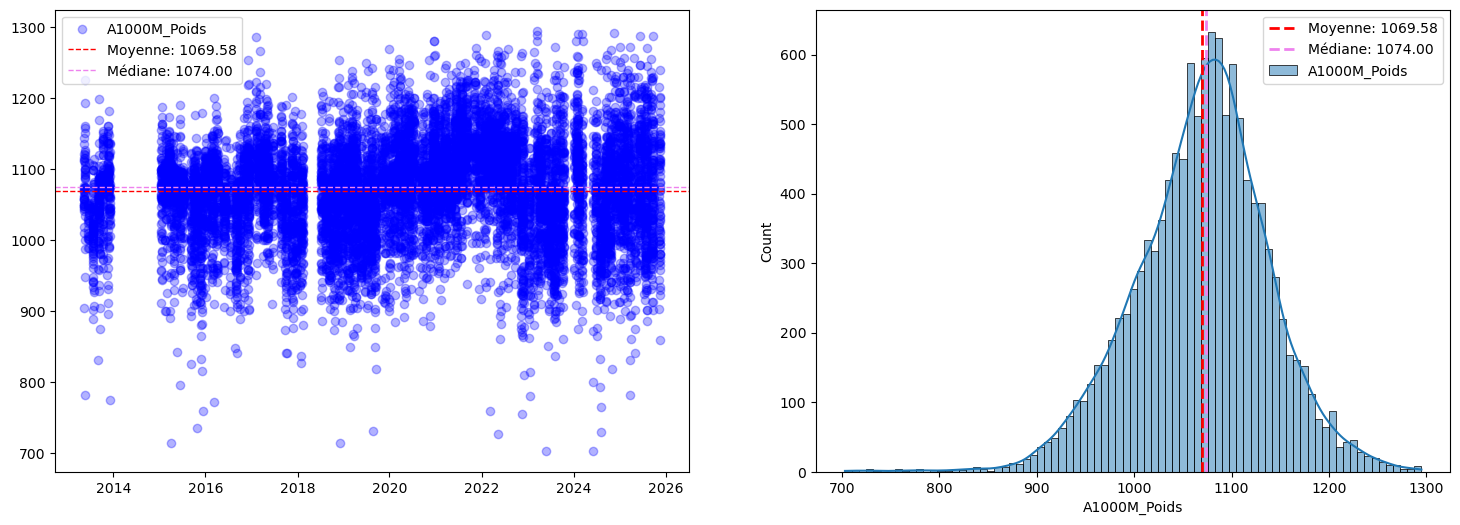

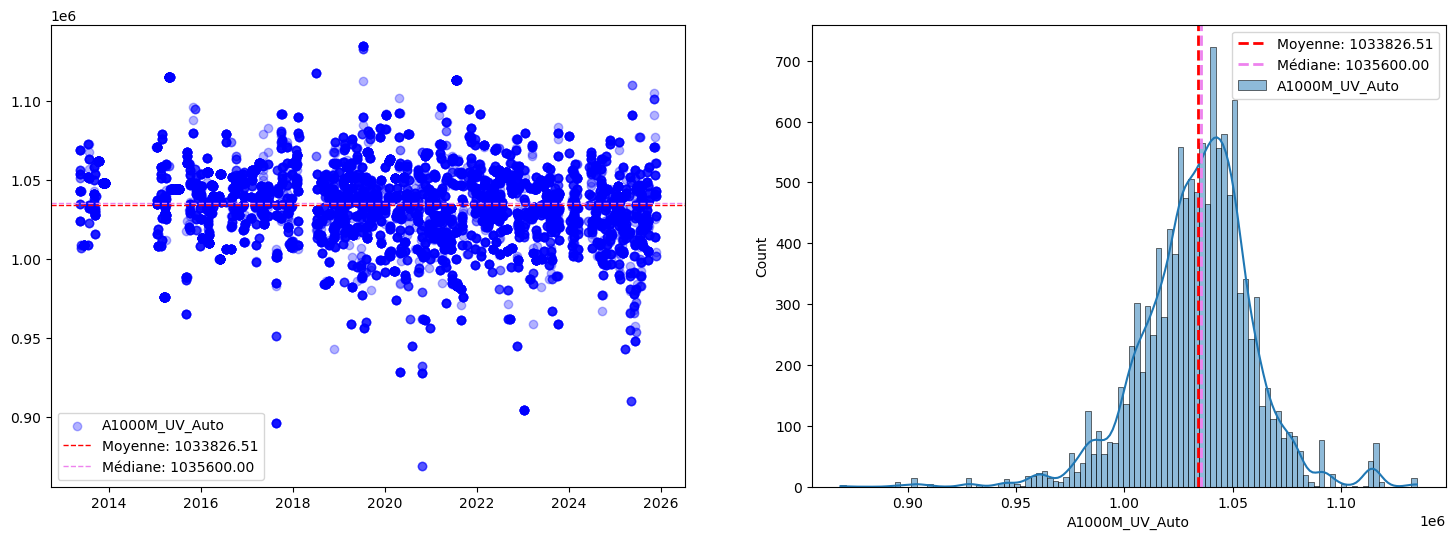

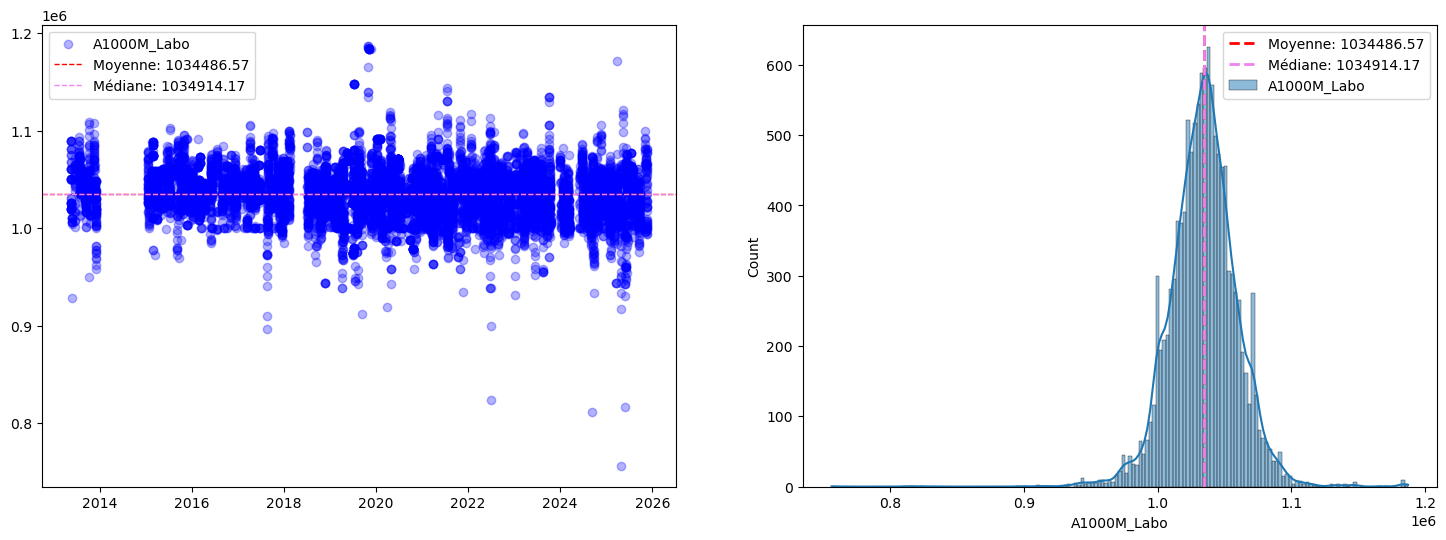

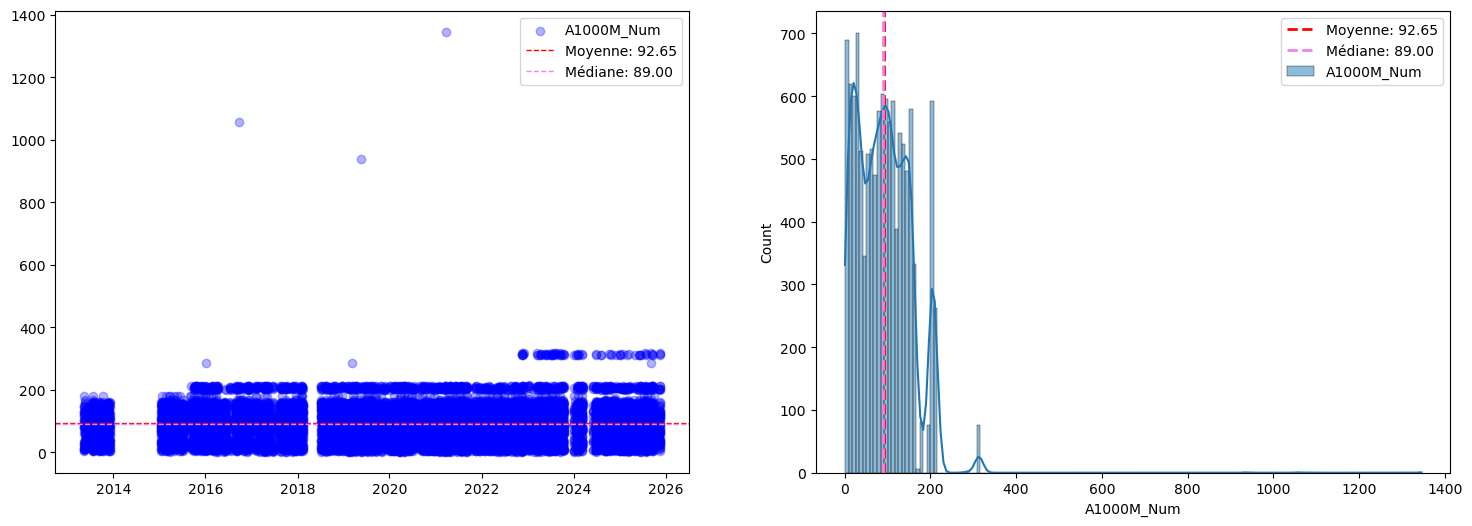

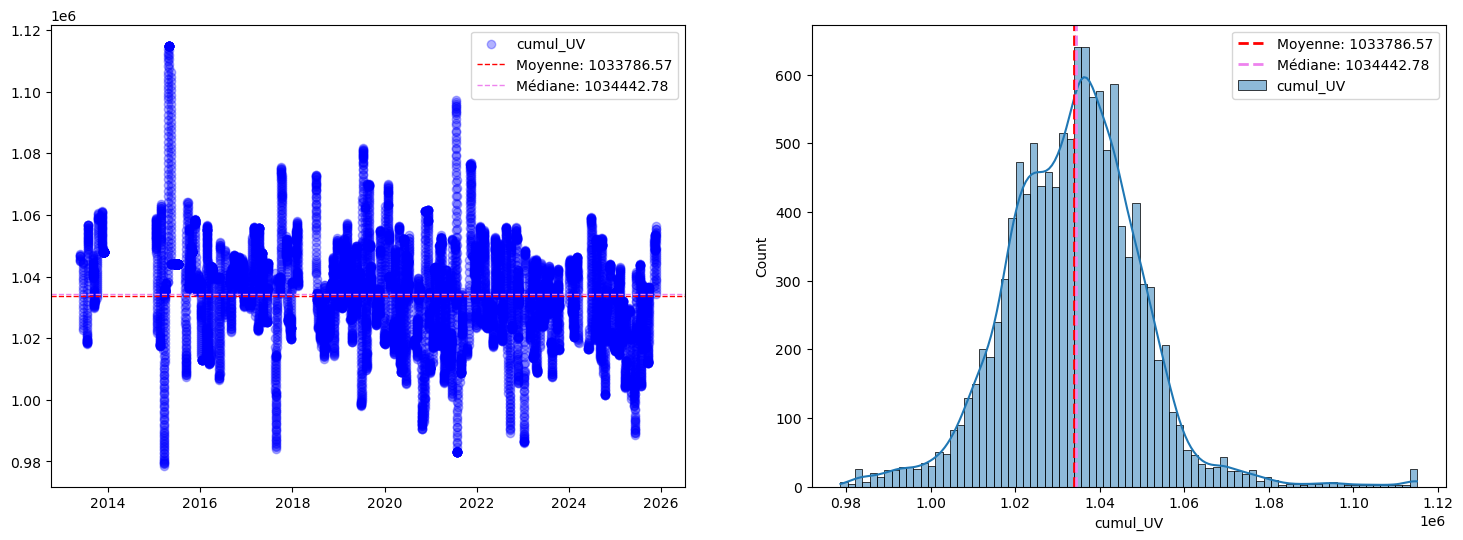

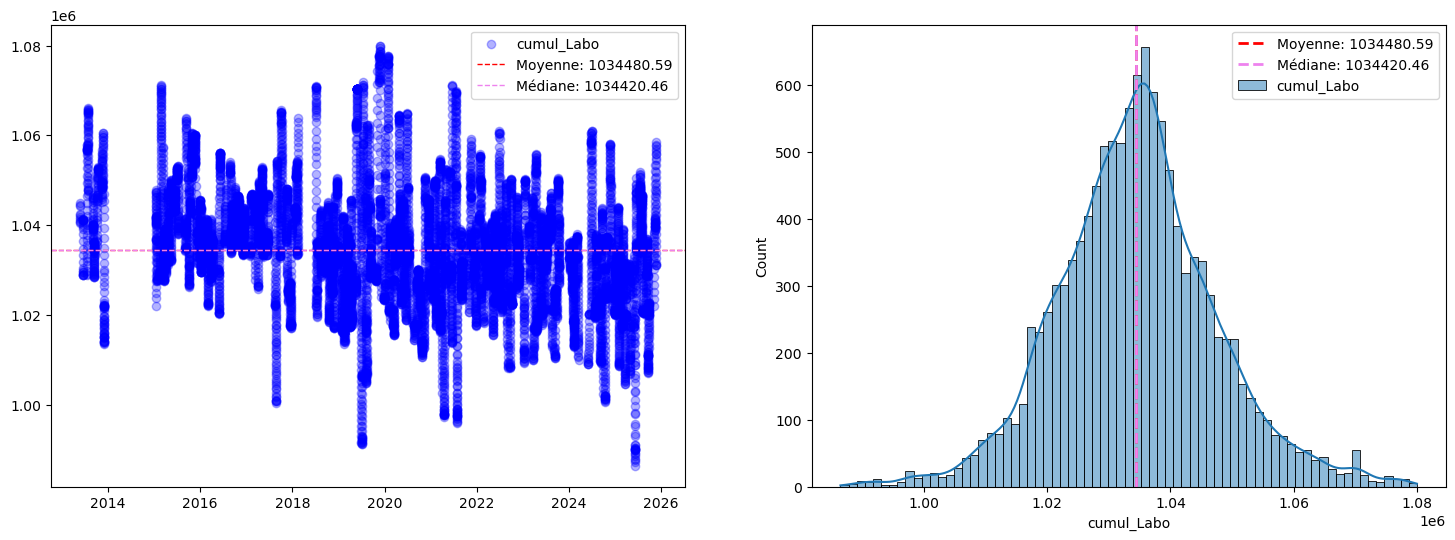

In [20]:
df_ = brute.copy()
df_ = filtering(df_)
# Repérer les changement de campagne de M->R et R->M
df_ = ajouter_element_campagne(df_, fill_empty=False)
# Séparation Campagnes A1000M et A1000R:
df_M, df_R = separer_elements(df_)
# Detect changement de campagne vs jours :
df_M= reincrementer_campagnes_par_temps(df_M, jours_seuil=2)
df_R_updated = reincrementer_campagnes_par_temps(df_R, jours_seuil=2)
df_M = ajouter_moyennes_glissantes(df_M,50)
#result = detecter_campagnes_v2(result, seuil_jours=14)
campagnes = resume_par_campagne(df_M)
tags_ = df_M.columns.tolist()[:-3]
df_M_tags =  ['A1000M_Poids','A1000M_UV_Auto','A1000M_Labo','A1000M_Num','cumul_UV','cumul_Labo']
plot_data(df_M, df_M_tags)

Campagnes identifiées : 186


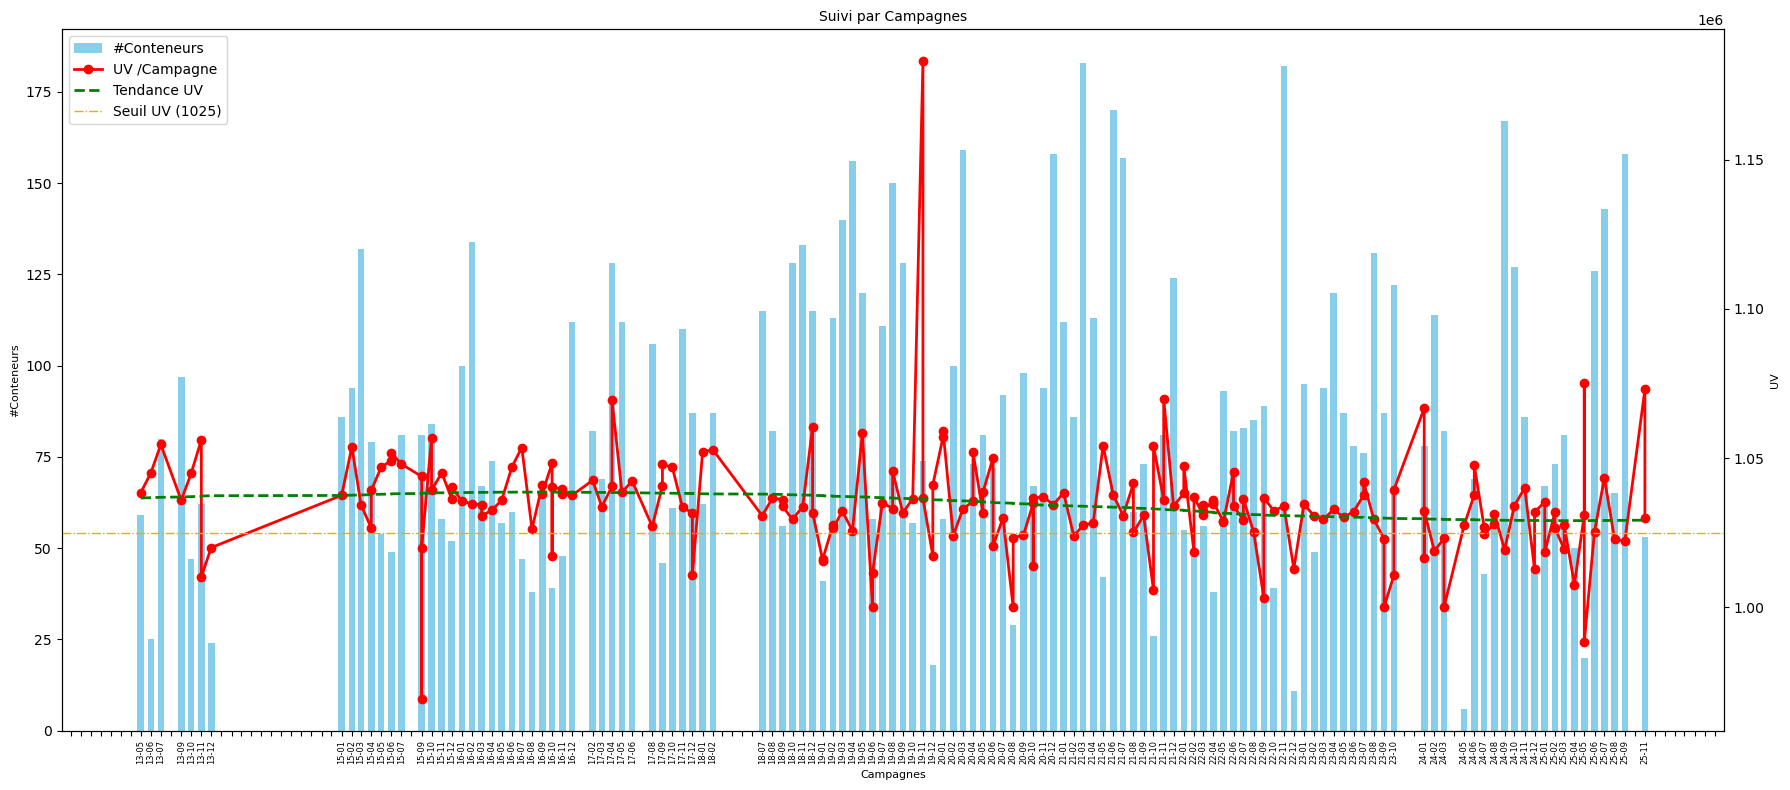

In [21]:
plot_campagnes_v5(campagnes)

In [22]:
def extract_xls(data,nom_fichier,index=False):
    df = data.copy()
    nom_fichier = nom_fichier+".xlsx"
    if (index):
        # Supprimer la timezone de l'index
        if df.index.tz is not None:
            df.index = df.index.tz_localize(None)

        # Corriger TOUTES les colonnes datetime avec timezone
        for col in df.columns:
            # Vérifier si c'est une colonne datetime
            if pd.api.types.is_datetime64_any_dtype(df[col]):
                # Si elle a une timezone, la supprimer
                if df[col].dt.tz is not None:
                    df[col] = df[col].dt.tz_localize(None)

    df.to_excel(nom_fichier, index=index)

    # Créer un lien de téléchargement
    #FileLink(fichier)
    display(HTML(f'<a href="{nom_fichier}" download>Télécharger les Data de ${nom_fichier}</a>'))

In [23]:
def extract():
    extract_xls(brute,'Formulation_brute',True)
    extract_xls(data,'Formulation_OI',True)
    extract_xls(result,'Formulation_traitees',True)
    extract_xls(campagnes,'Formulation_Campagnes',False)


In [24]:
# Convertir en Excel
fichier = 'Campagnes.xlsx'
campagnes.to_excel(fichier, index=False)

# Créer un lien de téléchargement
#FileLink(fichier)
#display(HTML(f'<a href="{fichier}" download>Télécharger le fichier Excel</a>'))

# Créer un bouton de téléchargement
html = f'''
<a href="data:application/vnd.openxmlformats-officedocument.spreadsheetml.sheet;base64,{data}" 
   download="{fichier}">
   <button>Télécharger Excel</button>
</a>
'''
display(HTML(html))